In [1]:
# setting root at top

import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))

# WeightLossModel 224x224 Image and 5 Conv Blocks
# Using Class Weigh Loss and 0.002 Learning Rate

### Import libraries
* `torch`
* `datasets` and `transforms` from `torchvision` for data Loading.
* `DataLoader` and `WeightedRandomSampler` from `torch.utils.data` for Batching and using data in model.
* `NormModel` from `architectures.NormModel.py`
* `pandas` as `pd`
* `matplotlib.pyplot` as `plt`
* `seaborn` as sns
* `trainer` from `modules.TrainTest`
* `compute_class_weights` from `modules.ClassWeights`

In [2]:
# training and architecture
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from architectures.WeightLossModel import WeightLossModel

# visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#trainer and tester modules
from modules.TrainTest import trainer
from modules.ClassWeights import compute_class_weights

### Load datasets for training
* load 64x64 images
* load from `../dataset/final-dataset/train`
* convert to tensor
* make batch_size = 16

In [3]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.35),
    transforms.RandomRotation(8),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.3)
])

train_dataset = datasets.ImageFolder(
    root="../dataset/final-dataset/train",
    transform=train_transform
)

In [4]:

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
)

class_weights = compute_class_weights(dataloader=train_dataloader)

### Load datasets for training
* load 64x64 images
* load from `../dataset/final-dataset/train`
* convert to tensor
* make batch_size = 32

In [7]:
valid_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ]
)

valid_dataset = datasets.ImageFolder(
    root="../dataset/final-dataset/valid",
    transform=valid_transform
)

valid_dataloader = DataLoader(
    dataset=valid_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

### Use Model for training
Initialize model using 
* `conv_layers = 5`, 
* `initial_output_channel = 16` 
* `initial_image_size = 224`
* `poolings = [1,1,1,1,1]`
* `normalizations = [1, 1, 1, 1, 1]`,
* `dropouts = [0, 0, 1, 0, 1]`

In [8]:
model = WeightLossModel(
    conv_layers=5, 
    normalizations = [1, 1, 1, 1, 1],
    poolings = [1, 1, 1, 1, 1],
    dropouts = [0, 0, 1, 0, 1],
    initial_output_channel=16, 
    initial_image_size=224,
    dropout_p = 0.2,
    class_weights = class_weights
    ).to("cuda")

In [9]:
metrics = trainer(
    model=model,
    train_dataloader=train_dataloader,
    test_dataloader=valid_dataloader,
    epoch=60,
    lr=0.002,
    print_on=5,
    save_dir="../models/wl_img224_lr_0.002/",
    save_checkpoints=1,
    checkpoint_name="wl_224x224_train_0_",
    early_stop_patience = 20,
    min_delta = 0.001
)

Epoch 5/60 | Train Loss: 0.7873 | Valid Loss: 1.7517
Epoch 10/60 | Train Loss: 0.5805 | Valid Loss: 1.2296
Epoch 15/60 | Train Loss: 0.4677 | Valid Loss: 1.3723
Epoch 20/60 | Train Loss: 0.3817 | Valid Loss: 4.0206
Early stopping at epoch 23 | No improvement for 20 epochs


## Visualize

Convert metrics to a pd.DataFrame and add epoch column for visualization.

In [10]:
metrics = pd.DataFrame(metrics)
epochs = [i+1 for i  in range(len(metrics))]
metrics["epoch"] = epochs

In [11]:
metrics

,epoch,training_loss,training_accuracy,training_precision,training_recall,training_f1,valid_loss,valid_accuracy,valid_precision,valid_recall,valid_f1
0,1,1.882974,0.463479,0.413855,0.473292,0.403663,1.102263,0.621770,0.527747,0.518100,0.513707
1,2,1.086235,0.555100,0.487116,0.566065,0.487257,1.561997,0.449809,0.465232,0.390016,0.316888
2,3,0.936365,0.596721,0.524230,0.624487,0.534497,0.972618,0.647183,0.558554,0.624277,0.562930
3,4,0.830067,0.633789,0.554971,0.656686,0.567765,1.127109,0.700974,0.596069,0.619811,0.604211
4,5,0.787329,0.658834,0.578103,0.686024,0.596420,1.751652,0.577298,0.599963,0.433121,0.406505
5,6,0.679010,0.683607,0.603028,0.716506,0.626537,1.182587,0.557391,0.571586,0.551094,0.449104
6,7,0.669081,0.692805,0.612923,0.731141,0.637821,1.413923,0.571792,0.595988,0.504836,0.470450
7,8,0.631856,0.701184,0.624191,0.740961,0.652947,1.152828,0.712834,0.610977,0.619839,0.607325
8,9,0.595789,0.720219,0.642433,0.757635,0.672630,2.799443,0.474799,0.603629,0.424741,0.346935
9,10,0.580535,0.733880,0.654830,0.768481,0.685449,1.229607,0.661584,0.588306,0.581900,0.553689


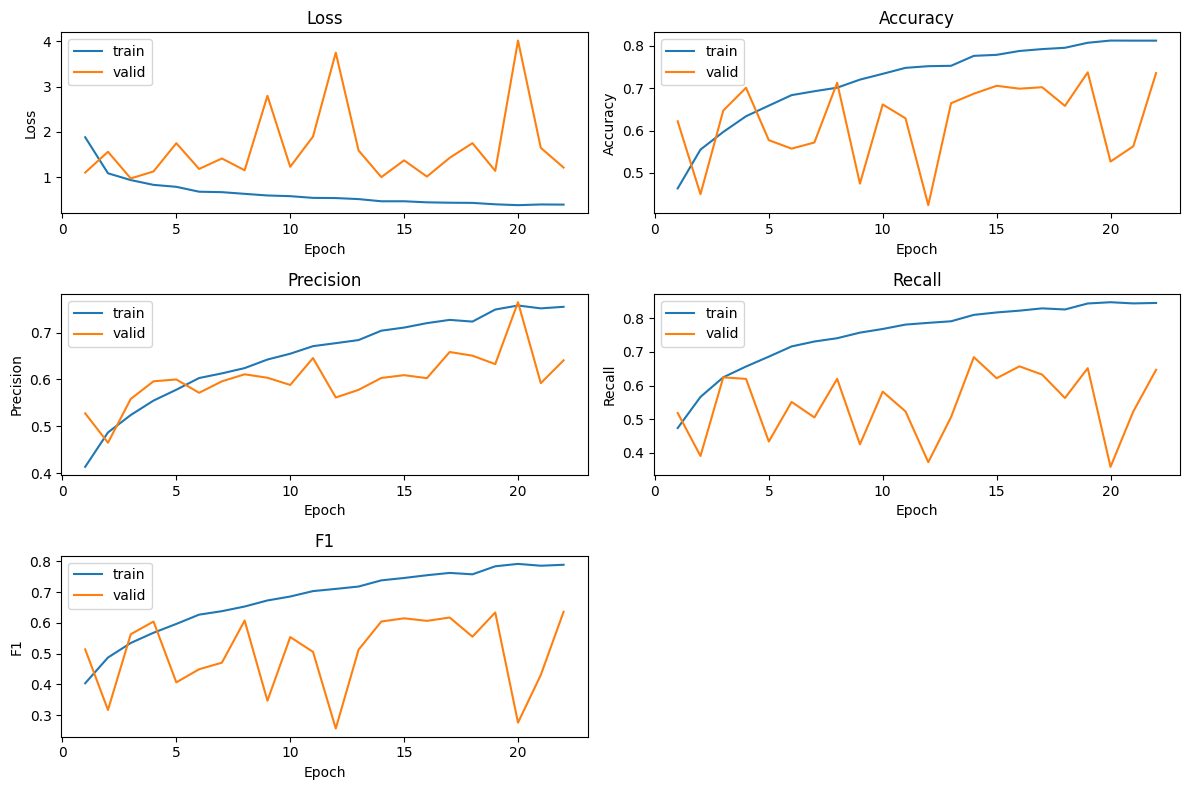

In [12]:
fig, axes = plt.subplots(3, 2, figsize=(12, 8))
axes = axes.flatten()

to_viz = [
    "loss",
    "accuracy",
    "precision",
    "recall",
    "f1"
]

for i, metric in enumerate(to_viz):

    ax = axes[i]

    sns.lineplot(
        data=metrics,
        x="epoch",
        y=f"training_{metric}",
        ax=ax,
        label="train"
    )

    sns.lineplot(
        data=metrics,
        x="epoch",
        y=f"valid_{metric}",
        ax=ax,
        label="valid"
    )

    ax.set_title(metric.capitalize())
    ax.set_xlabel("Epoch")
    ax.set_ylabel(metric.capitalize())

# Hide unused subplot (6th slot)
axes[-1].axis("off")

plt.tight_layout()
plt.show()